In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)

In [42]:
df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [25]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 16
Columns: 2


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Column Name  16 non-null     object
 1   Definition   16 non-null     object
dtypes: object(2)
memory usage: 388.0+ bytes


In [27]:
df.head()

,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account


In [28]:
df.columns.tolist()

['Column Name', 'Definition']

In [29]:
df.describe().T

,count,unique,top,freq
Column Name,16,16,TransactionId,1
Definition,16,16,Unique �transaction identifier on platform,1


In [30]:
df.describe(include="object").T

,count,unique,top,freq
Column Name,16,16,TransactionId,1
Definition,16,16,Unique �transaction identifier on platform,1


In [31]:
missing = df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Column Name,0,0.0
Definition,0,0.0


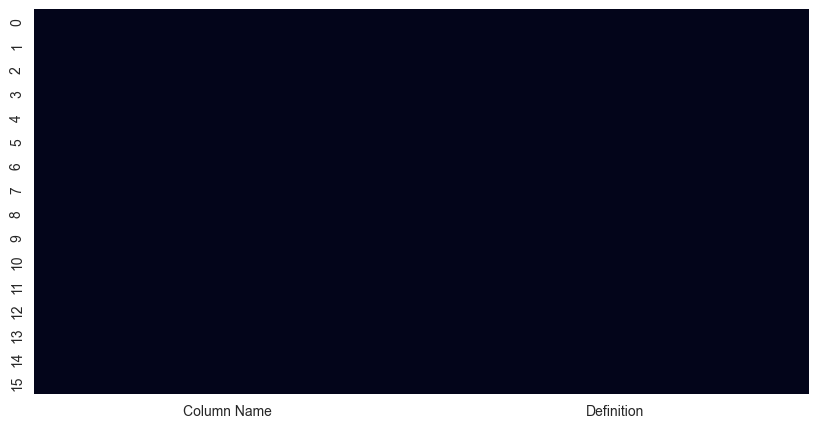

In [32]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [38]:
num_cols = df.select_dtypes(include=np.number).columns

In [34]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

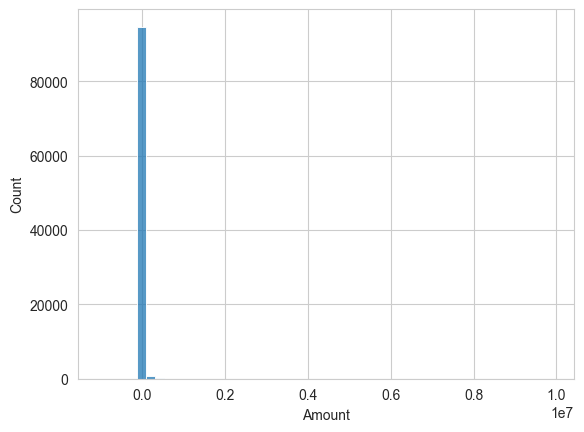

In [39]:
sns.histplot(df["Amount"], bins=50)
plt.show()

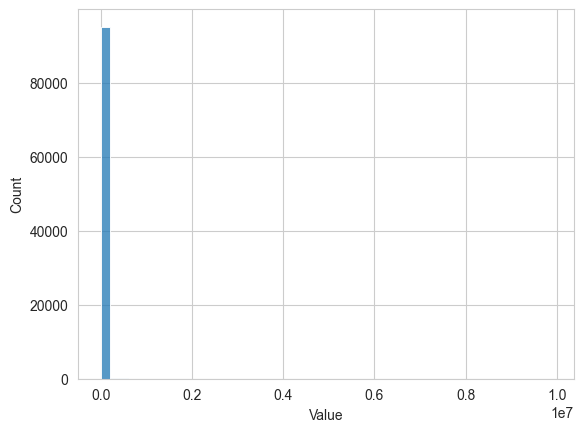

In [40]:
sns.histplot(df["Value"], bins=50)
plt.show()

In [41]:
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in num_cols]  # ensure no overlap
cat_cols

['TransactionId',
 'BatchId',
 'AccountId',
 'SubscriptionId',
 'CustomerId',
 'CurrencyCode',
 'ProviderId',
 'ProductId',
 'ProductCategory',
 'ChannelId',
 'TransactionStartTime']

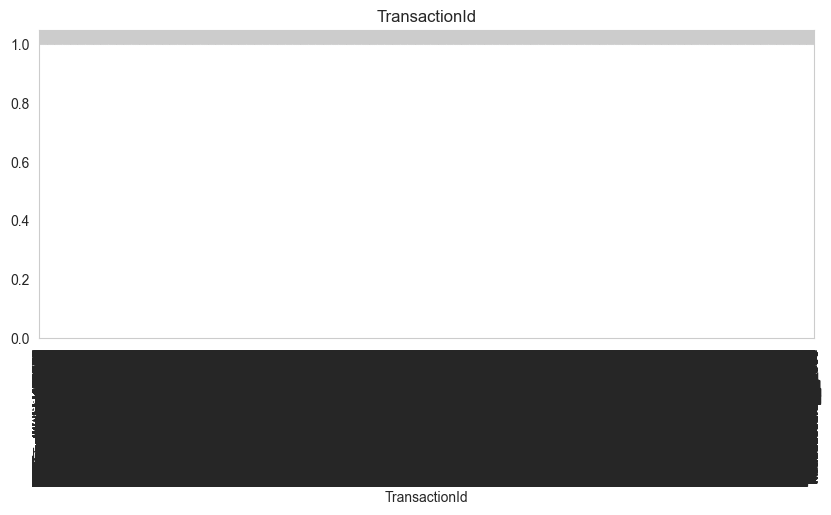

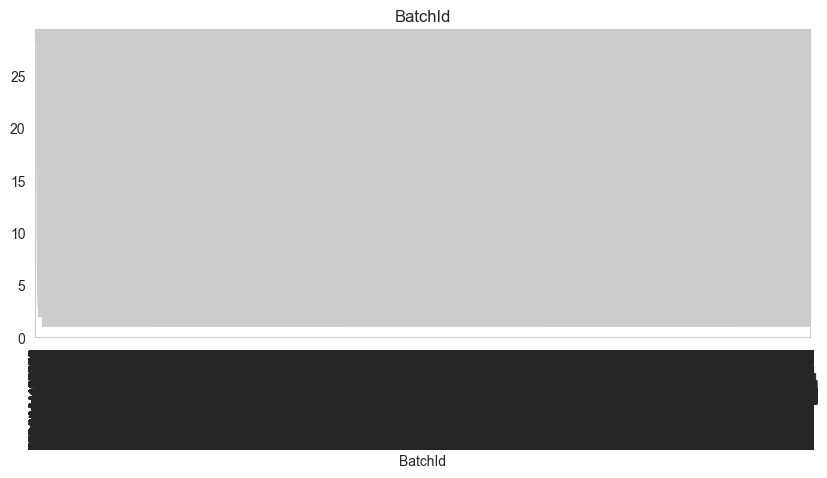

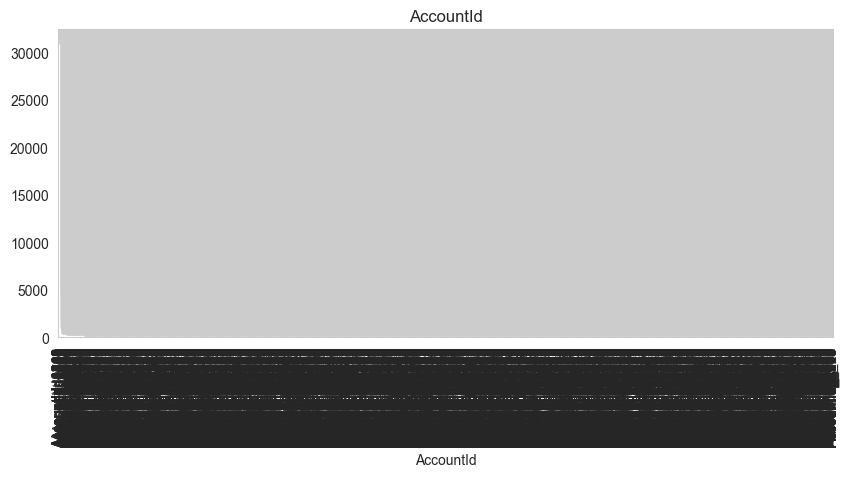

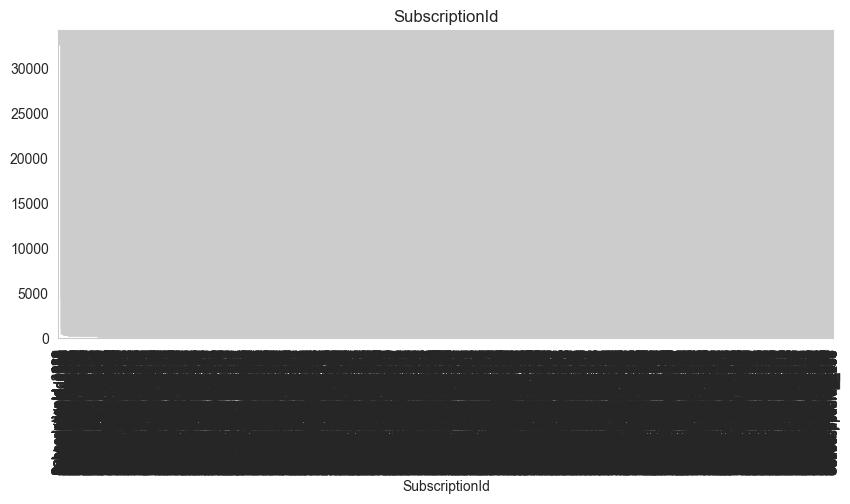

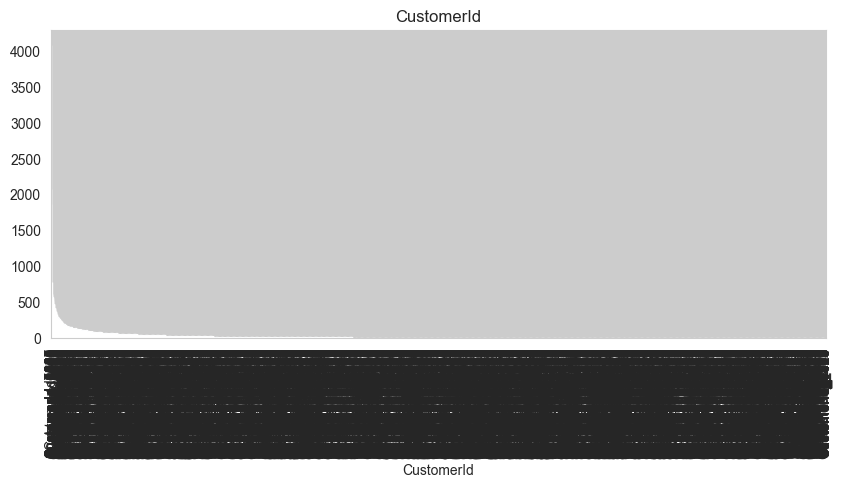

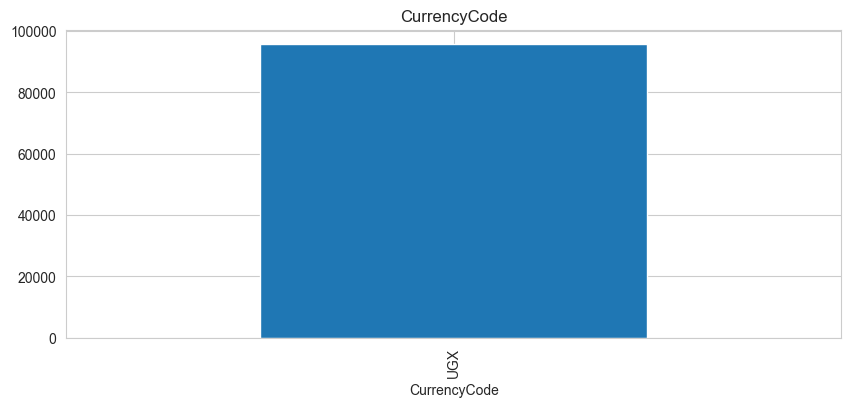

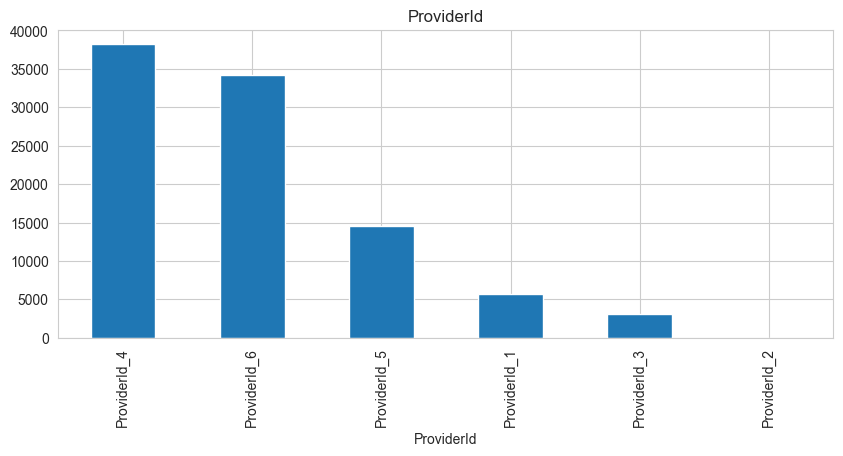

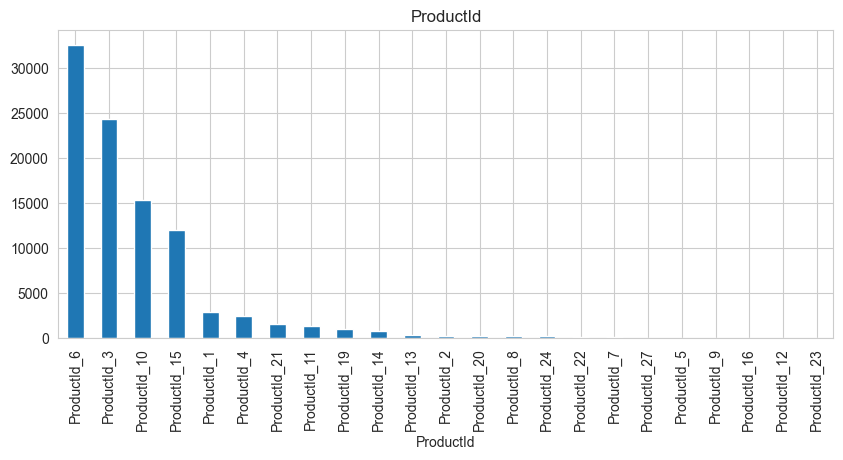

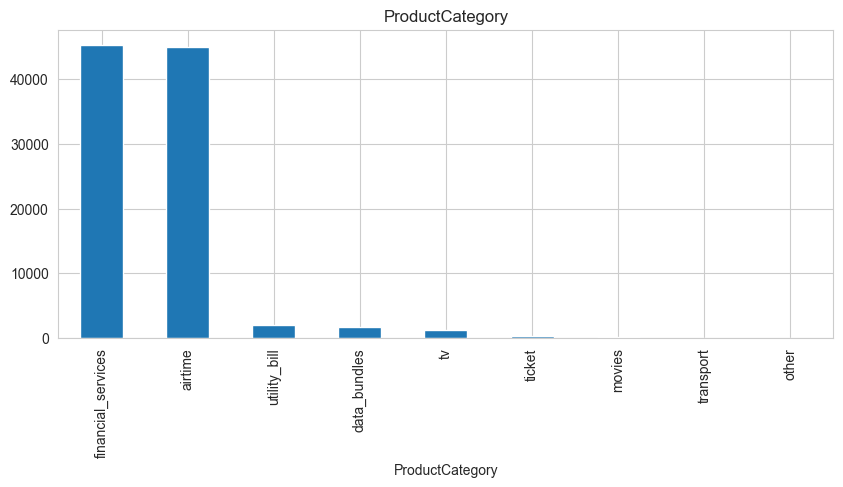

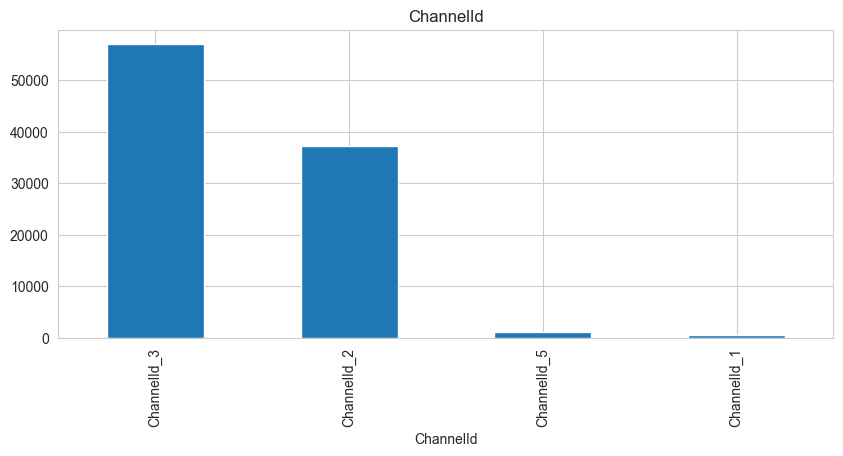

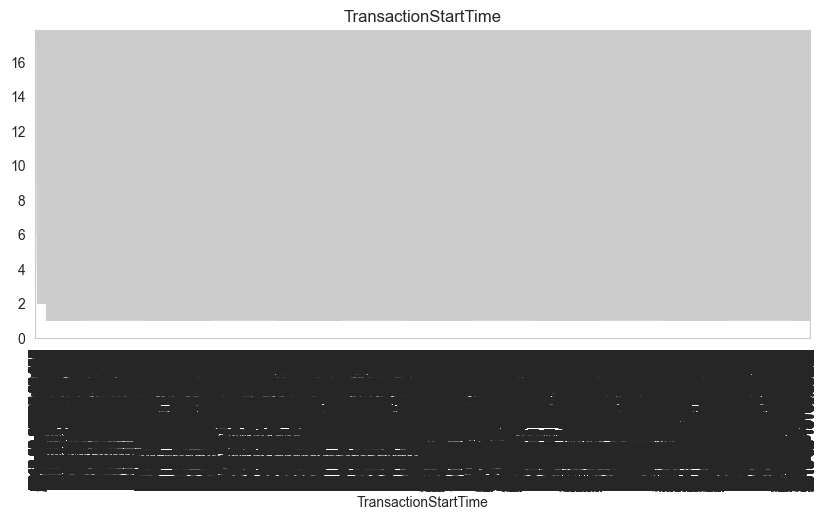

In [43]:
for col in cat_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

In [20]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [21]:
df["year"] = df["TransactionStartTime"].dt.year
df["month"] = df["TransactionStartTime"].dt.month
df["day"] = df["TransactionStartTime"].dt.day
df["hour"] = df["TransactionStartTime"].dt.hour

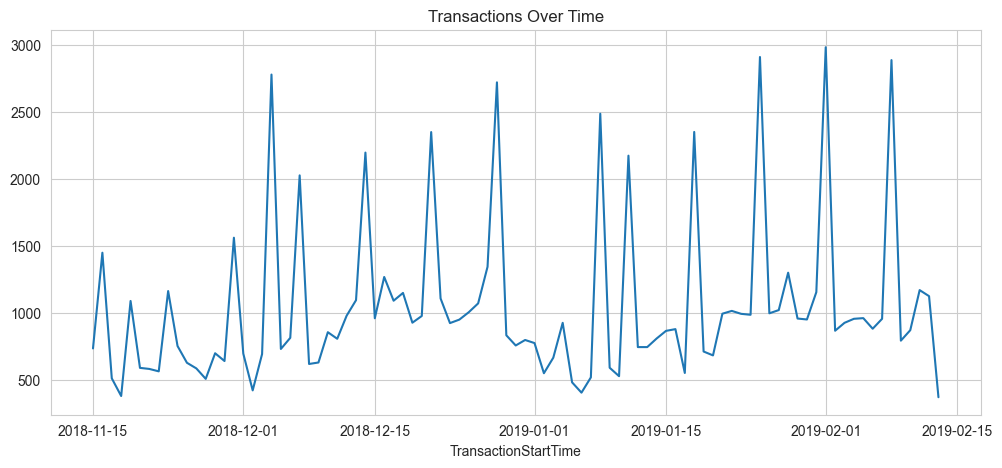

In [22]:
daily_tx = df.groupby(df["TransactionStartTime"].dt.date).size()

daily_tx.plot(figsize=(12,5))
plt.title("Transactions Over Time")
plt.show()

In [ ]:
corr = df[num_cols].corr()

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.show()

In [ ]:
df["FraudResult"].value_counts()

In [ ]:
sns.countplot(x="FraudResult", data=df)
plt.show()

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Amount"])
plt.show()

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Value"])
plt.show()

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
df["CustomerId"].nunique()

In [ ]:
customer_tx = (
    df.groupby("CustomerId")
      .size()
)

customer_tx.describe()

In [ ]:
sns.histplot(customer_tx, bins=50)
plt.show()

# Key Insights

1. Transaction Amount and Value are highly skewed with significant outliers, suggesting that log transformation may improve model performance.

2. Customer transaction behavior varies substantially, indicating that Recency, Frequency, and Monetary (RFM) metrics are likely to be strong predictors of customer risk.

3. Certain payment channels and product categories dominate platform activity, which may provide valuable behavioral signals for credit scoring.

4. Fraud cases are highly imbalanced, but fraud history could serve as an informative risk-related feature.

5. Strong correlation exists between Amount and Value, suggesting possible redundancy and the need for feature selection during model development.

In [4]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_processing import build_pipeline
import pandas as pd

df = pd.read_csv("../data/raw/data.csv")

pipe = build_pipeline()

X_processed = pipe.fit_transform(df)

print(X_processed.shape)

(95662, 34)
